In [ ]:
import ee
import geemap
import pandas as pd
import numpy as np
import time
import os
from google.colab import files
import geopandas as gpd
import json
import numpy as np
from glob import glob
from google.colab import drive
import matplotlib.pyplot as plt

# Authenticate and initialize
ee.Authenticate()
ee.Initialize(project='gee-470209')    # eg. project name: 'gee-470209'

# Add Study area as geojason. Projection must be in wgs84

In [ ]:
# Define the desired directory path
target_directory = '/content/Aoi'
uploaded = files.upload(target_directory)

In [ ]:
# Load GeoJSON
with open("/content/Aoi/Aoi_Point.geojson") as f:
    geojson_data = json.load(f)

# Convert to EE Geometry or FeatureCollection
roi = ee.FeatureCollection(geojson_data)
first_feature = roi.first()
print('Segment Processing Start',first_feature.get('FID').getInfo())

In [ ]:
# Load GeoJSON
with open("/content/Aoi/AOI_Ganges.geojson") as f:
    geojson_data = json.load(f)

# Convert to EE Geometry or FeatureCollection
roi_ganges = ee.FeatureCollection(geojson_data)
roi_ganges = roi_ganges.first()
print('Segment Processing Start',roi_ganges.get('FID').getInfo())

# Check Image Availability Corrosponding SSC date

In [ ]:
# @title
import ee, pandas as pd

# ---------- 1. Load SSC dates (auto-detect date column) ----------
ssc = pd.read_excel('/content/Aoi/Data_SSC.xlsx', sheet_name='Sheet2')  # match your filename
date_col = 'Date' if 'Date' in ssc.columns else 'HB'
ssc['Date'] = pd.to_datetime(ssc[date_col], errors='coerce')
ssc = ssc.dropna(subset=['Date']).reset_index(drop=True)
ssc = ssc[ssc['Date'] >= '1984-03-01'].reset_index(drop=True)
print(f'Usable SSC dates (1984+): {len(ssc)}\n')

# ---------- 2. Location + collections ----------
point = roi.geometry()
COLLECTIONS = {
    'LT05': 'LANDSAT/LT05/C02/T1_L2',
    'LE07': 'LANDSAT/LE07/C02/T1_L2',
    'LC08': 'LANDSAT/LC08/C02/T1_L2',
    'LC09': 'LANDSAT/LC09/C02/T1_L2',
}
WINDOW = 2   # +/- days around SSC date

# ---------- 3. Check each date, print result ----------
print(f'{"SSC_date":<12} {"#":<3} image available')
print('-' * 36)

records = []
for ds in ssc['Date'].dt.strftime('%m/%d/%Y'):
    d0 = ee.Date(pd.to_datetime(ds).strftime('%Y-%m-%d'))
    start, end = d0.advance(-WINDOW, 'day'), d0.advance(WINDOW + 1, 'day')

    found = []
    for m, cid in COLLECTIONS.items():
        n = (ee.ImageCollection(cid)
               .filterDate(start, end)
               .filterBounds(point)
               .size().getInfo())
        if n > 0:
            found.append(m.replace('LT05','ls5').replace('LE07','ls7')
                          .replace('LC08','ls8').replace('LC09','ls9'))

    avail = ', '.join(found) if found else 'none'
    num = len(found)                       # how many sensors have an image
    print(f'{ds:<12} {num:<3} {avail}')
    records.append({'SSC_date': ds, 'num_sources': num, 'image_available': avail})

# ---------- 4. Save table ----------
out = pd.DataFrame(records)
out.to_csv('ssc_image_availability.csv', index=False)
print(f'\nSaved ssc_image_availability.csv  ({len(out)} rows)')
print(f'Dates with an image: {(out["num_sources"] > 0).sum()}')
print(f'Dates with no image: {(out["num_sources"] == 0).sum()}')

# breakdown: how many dates had 1, 2, 3... sensors available
print('\nSources per date:')
print(out["num_sources"].value_counts().sort_index().to_string())

# breakdown: total availability per individual sensor
print('\nDates covered by each sensor:')
for m in ['ls5','ls7','ls8','ls9']:
    c = out['image_available'].str.contains(m).sum()
    print(f'  {m}: {c}')

# Collet Reflectance for all band

In [ ]:
# @title
import ee, pandas as pd

# ---------- 1. Load SSC data (auto-detect date column) ----------
ssc = pd.read_excel('/content/Aoi/Data_SSC.xlsx', sheet_name='Sheet2')  # match filename
date_col = 'Date' if 'Date' in ssc.columns else 'HB'
ssc['Date'] = pd.to_datetime(ssc[date_col], errors='coerce')
ssc = ssc.dropna(subset=['Date']).reset_index(drop=True)
ssc = ssc[ssc['Date'] >= '1984-03-01'].reset_index(drop=True)

# SSC concentration column (this file already has SSC_PPM)
ssc_col = 'SSC_PPM' if 'SSC_PPM' in ssc.columns else None
print(f'Usable SSC dates (1984+): {len(ssc)}')

# ---------- 2. Location + buffer ----------
point  = roi.geometry()
region = point.buffer(90)          # ~3x3 Landsat pixels; tune to channel width

# ---------- 3. Collections + band harmonization ----------
BANDS = ['Blue','Green','Red','NIR','SWIR1','SWIR2']

def scale_sr(img):
    return img.addBands(img.select('SR_B.').multiply(0.0000275).add(-0.2),
                        None, True)

def mask_qa(img):
    qa = img.select('QA_PIXEL')
    dilated = qa.bitwiseAnd(1 << 1).neq(0)
    cirrus  = qa.bitwiseAnd(1 << 2).neq(0)
    cloud   = qa.bitwiseAnd(1 << 3).neq(0)
    shadow  = qa.bitwiseAnd(1 << 4).neq(0)
    bad = dilated.Or(cirrus).Or(cloud).Or(shadow)
    return img.updateMask(bad.Not())

def prep_L5L7(img):
    img = mask_qa(scale_sr(img))
    img = img.select(['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B7'], BANDS)
    ndwi = img.normalizedDifference(['Green','NIR']).rename('NDWI')
    return img.updateMask(ndwi.gt(0))     # keep only water

def prep_L8L9(img):
    img = mask_qa(scale_sr(img))
    img = img.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'], BANDS)
    ndwi = img.normalizedDifference(['Green','NIR']).rename('NDWI')
    return img.updateMask(ndwi.gt(0))

COLLECTIONS = {   # label : (asset, prep fn)
    'ls5': ('LANDSAT/LT05/C02/T1_L2', prep_L5L7),
    'ls7': ('LANDSAT/LE07/C02/T1_L2', prep_L5L7),
    'ls8': ('LANDSAT/LC08/C02/T1_L2', prep_L8L9),
    'ls9': ('LANDSAT/LC09/C02/T1_L2', prep_L8L9),
}
WINDOW = 2

# ---------- 4. Collect reflectance per SSC date ----------
records = []
dates = ssc['Date'].dt.strftime('%Y-%m-%d').tolist()

for i, ds in enumerate(dates):
    d0 = ee.Date(ds)
    start, end = d0.advance(-WINDOW,'day'), d0.advance(WINDOW+1,'day')

    best = None                    # (label, image_date, values, n)
    for label, (cid, prep) in COLLECTIONS.items():
        col = (ee.ImageCollection(cid)
                 .filterDate(start, end)
                 .filterBounds(point))
        n = col.size().getInfo()
        if n == 0:
            continue
        # nearest scene to the SSC date
        col = col.map(lambda im: im.set(
            'dt', ee.Number(im.date().difference(d0,'day')).abs()))
        img = ee.Image(col.sort('dt').first())
        vals = prep(img).reduceRegion(
            reducer=ee.Reducer.mean(), geometry=region,
            scale=30, maxPixels=1e9).getInfo()
        # skip if cloud-masked out (Red is None)
        if vals.get('Red') is None:
            continue
        idate = img.date().format('YYYY-MM-dd').getInfo()
        best = (label, idate, vals, n)
        break                      # take first mission that yields clear pixels

    rec = {'Date': pd.to_datetime(ds).strftime('%m/%d/%Y')}
    if best:
        label, idate, vals, n = best
        for b in BANDS:
            rec[b] = round(vals[b], 5) if vals.get(b) is not None else None
        # days gap between SSC date and actual image date
        gap = int(abs((pd.to_datetime(idate) - pd.to_datetime(ds)).days))
        rec['Source']     = label
        rec['Image_Date'] = pd.to_datetime(idate).strftime('%m/%d/%Y')
        rec['days_gap']   = gap
        rec['Remarks']    = ''
    else:
        for b in BANDS:
            rec[b] = 'none'
        rec['Source']     = 'none'
        rec['Image_Date'] = 'none'
        rec['days_gap']   = 'none'
        rec['Remarks']    = 'noimage'

    if ssc_col:
        rec['SSC_PPM'] = ssc.loc[i, ssc_col]

    records.append(rec)
    if (i+1) % 25 == 0:
        print(f'  processed {i+1}/{len(dates)}')

# ---------- 5. Build table & save ----------
cols = ['Date'] + BANDS + (['SSC_PPM'] if ssc_col else []) \
       + ['Source','Image_Date','days_gap','Remarks']
db = pd.DataFrame(records)[cols]
db.to_csv('reflectance_database.csv', index=False)

print('\nSaved reflectance_database.csv:', db.shape)
print('With image:', (db['Source'] != 'none').sum(),
      '| No image:', (db['Source'] == 'none').sum())

# gap distribution (only matched rows)
matched = db[db['Source'] != 'none']
print('\ndays_gap distribution:')
print(matched['days_gap'].value_counts().sort_index().to_string())
print('\nMatches per sensor:')
print(matched['Source'].value_counts().to_string())

db.head(25)

In [7]:
# @title  Band-ratio R2 table (Peterson-style Table 3)
import pandas as pd, numpy as np
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# ---------- 1. LOAD & CLEAN ----------
df = pd.read_csv('/content/reflectance_database.csv')
BANDS = ['Blue','Green','Red','NIR','SWIR1','SWIR2']
for c in BANDS + ['SSC_PPM']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df[df['Source'] != 'none'].dropna(subset=BANDS + ['SSC_PPM'])
df = df[(df['NIR'] > 0.001) & (df['NIR'] < 0.20) & (df['SSC_PPM'] >= 0)].reset_index(drop=True)
print(f'Clean samples: {len(df)}')
print('Per sensor:', df['Source'].value_counts().to_dict(), '\n')

# ---------- 2. DEFINE PREDICTORS (same as Peterson Table 3) ----------
def predictors(d):
    return {
        '(Green+Red)/2': (d['Green'] + d['Red']) / 2,
        'Green/Red':      d['Green'] / d['Red'],
        'Red/Green':      d['Red'] / d['Green'],
        'NIR/Green':      d['NIR'] / d['Green'],
        'Red/Green + NIR': None,   # special: 2-variable regression, handled below
        'Red':            d['Red'],
        'NIR':            d['NIR'],
    }

# ---------- 3. R2 FUNCTIONS ----------
def r2_single(x, y):
    """linear R2 between a single predictor and SSC"""
    x = np.asarray(x, float); y = np.asarray(y, float)
    ok = np.isfinite(x) & np.isfinite(y)
    if ok.sum() < 5: return np.nan
    # linear fit
    b, a = np.polyfit(x[ok], y[ok], 1)
    return r2_score(y[ok], b*x[ok] + a)

def r2_multi(X, y):
    """multiple linear regression R2 (e.g. Red/Green + NIR)"""
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    if ok.sum() < 5: return np.nan
    m = LinearRegression().fit(X[ok], y[ok])
    return r2_score(y[ok], m.predict(X[ok]))

# ---------- 4. BUILD TABLE (per sensor + all pooled) ----------
ratio_names = ['(Green+Red)/2','Green/Red','Red/Green','NIR/Green',
               'Red/Green + NIR','Red','NIR']
sensors = ['ls5','ls7','ls8','ls9']
# keep only sensors that actually have data
sensors = [s for s in sensors if (df['Source']==s).sum() >= 5]
groups = {s: df[df['Source']==s] for s in sensors}
groups['ALL'] = df

table = {}
for gname, g in groups.items():
    y = g['SSC_PPM'].values.astype(float)
    P = predictors(g)
    col = {}
    for rname in ratio_names:
        if rname == 'Red/Green + NIR':
            X = np.column_stack([(g['Red']/g['Green']).values, g['NIR'].values])
            col[rname] = r2_multi(X, y)
        else:
            col[rname] = r2_single(P[rname].values, y)
    table[f'{gname} (n={len(g)})'] = col

table_df = pd.DataFrame(table).reindex(ratio_names).round(3)
print('===== Band-ratio R2 table (linear correlation with SSC) =====')
print(table_df.to_string())
table_df.to_csv('band_ratio_R2_table.csv')
print('\nSaved band_ratio_R2_table.csv')

Clean samples: 50
Per sensor: {'ls7': 19, 'ls8': 16, 'ls5': 15} 

===== Band-ratio R2 table (linear correlation with SSC) =====
                 ls5 (n=15)  ls7 (n=19)  ls8 (n=16)  ALL (n=50)
(Green+Red)/2         0.047       0.379       0.467       0.220
Green/Red             0.070       0.518       0.535       0.400
Red/Green             0.070       0.630       0.675       0.473
NIR/Green             0.245       0.505       0.452       0.363
Red/Green + NIR       0.176       0.690       0.703       0.479
Red                   0.055       0.458       0.568       0.279
NIR                   0.172       0.623       0.502       0.329

Saved band_ratio_R2_table.csv


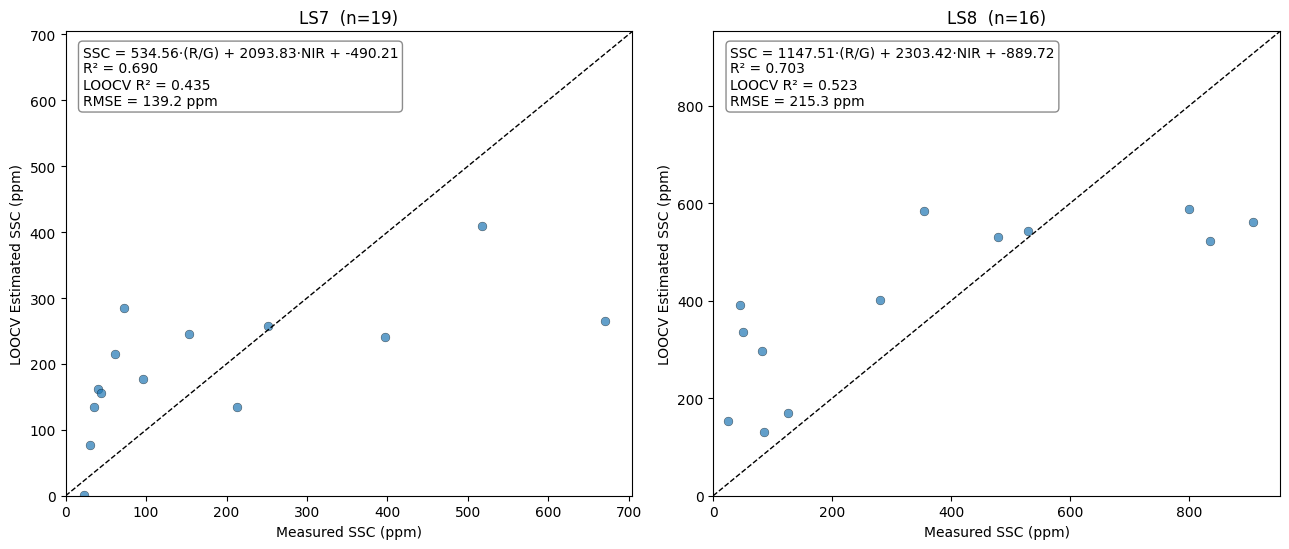

===== Red/Green + NIR  (SSC = a*(R/G) + b*NIR + c) =====

LS7  (n=19)
  Equation : SSC = 534.5638*(R/G) + 2093.8254*NIR + -490.2084
  In-sample R2 = 0.690 | LOOCV R2 = 0.435 | RMSE = 139.2 ppm

LS8  (n=16)
  Equation : SSC = 1147.5125*(R/G) + 2303.4198*NIR + -889.7189
  In-sample R2 = 0.703 | LOOCV R2 = 0.523 | RMSE = 215.3 ppm

Saved: ls7_ls8_models.png


In [8]:
# @title  LS7 & LS8 separate models: SSC = a*(R/G) + b*NIR + c
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

# ---------- 1. LOAD & CLEAN ----------
df = pd.read_csv('/content/reflectance_database.csv')
BANDS = ['Blue','Green','Red','NIR','SWIR1','SWIR2']
for c in BANDS + ['SSC_PPM']:
    df[c] = pd.to_numeric(df[c], errors='coerce')
df = df[df['Source'] != 'none'].dropna(subset=BANDS + ['SSC_PPM'])
df = df[(df['NIR'] > 0.001) & (df['NIR'] < 0.20) & (df['SSC_PPM'] >= 0)].reset_index(drop=True)

# ---------- 2. FIT + LOOCV for one sensor ----------
def build(sensor):
    g = df[df['Source'] == sensor]
    X = np.column_stack([(g['Red']/g['Green']).values, g['NIR'].values]).astype(float)
    y = g['SSC_PPM'].values.astype(float)
    ok = np.isfinite(X).all(axis=1) & np.isfinite(y)
    X, y = X[ok], y[ok]
    n = len(y)

    # in-sample fit
    m = LinearRegression().fit(X, y)
    a, b = m.coef_; c = m.intercept_
    r2_in = r2_score(y, m.predict(X))

    # LOOCV
    pred = np.zeros_like(y, float)
    for tr, te in LeaveOneOut().split(X):
        mm = LinearRegression().fit(X[tr], y[tr])
        pred[te] = mm.predict(X[te])
    r2_cv = r2_score(y, pred)
    rmse_cv = np.sqrt(mean_squared_error(y, pred))

    return dict(sensor=sensor, n=n, a=a, b=b, c=c,
                r2_in=r2_in, r2_cv=r2_cv, rmse_cv=rmse_cv,
                y=y, pred=pred)

results = [build('ls7'), build('ls8')]

# ---------- 3. PLOT (equation written on each) ----------
fig, axes = plt.subplots(1, 2, figsize=(13, 5.6))

for ax, R in zip(axes, results):
    y, pred = R['y'], R['pred']
    lim = max(y.max(), pred.max()) * 1.05
    ax.scatter(y, pred, s=40, alpha=0.7, edgecolor='k', linewidth=0.3)
    ax.plot([0, lim], [0, lim], 'k--', lw=1)
    ax.set_xlim(0, lim); ax.set_ylim(0, lim)
    ax.set_xlabel('Measured SSC (ppm)')
    ax.set_ylabel('LOOCV Estimated SSC (ppm)')
    ax.set_title(f"{R['sensor'].upper()}  (n={R['n']})")

    eqn = (f"SSC = {R['a']:.2f}·(R/G) + {R['b']:.2f}·NIR + {R['c']:.2f}\n"
           f"R² = {R['r2_in']:.3f}\n"
           f"LOOCV R² = {R['r2_cv']:.3f}\n"
           f"RMSE = {R['rmse_cv']:.1f} ppm")
    ax.text(0.03, 0.97, eqn, transform=ax.transAxes,
            va='top', ha='left', fontsize=10,
            bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))

plt.tight_layout()
plt.savefig('ls7_ls8_models.png', dpi=150, bbox_inches='tight')
plt.show()

# ---------- 4. PRINT ----------
print('===== Red/Green + NIR  (SSC = a*(R/G) + b*NIR + c) =====\n')
for R in results:
    print(f"{R['sensor'].upper()}  (n={R['n']})")
    print(f"  Equation : SSC = {R['a']:.4f}*(R/G) + {R['b']:.4f}*NIR + {R['c']:.4f}")
    print(f"  In-sample R2 = {R['r2_in']:.3f} | LOOCV R2 = {R['r2_cv']:.3f} "
          f"| RMSE = {R['rmse_cv']:.1f} ppm\n")
print('Saved: ls7_ls8_models.png')

In [ ]:
# @title  LS8 SSC distribution maps — master river mask + time series
import ee

# ============================================================
#  PREREQS (already in your notebook):
#    roi_ganges  -> FeatureCollection (corridor boundary)
#    point       -> Hardinge Bridge point
#  LS8 SSC equation:  SSC = a*(R/G) + b*NIR + c
# ============================================================

corridor = roi_ganges.geometry()

# ---- your calibrated LS8 coefficients ----
A_RG  = 1013.6772     # coeff on Red/Green
B_NIR = 3162.1437     # coeff on NIR
C_INT = -894.9012     # intercept

# ---------- 1. LS8 COLLECTION, CLIPPED TO CORRIDOR ----------
def scale_sr(img):
    opt = img.select('SR_B.').multiply(0.0000275).add(-0.2)
    return img.addBands(opt, None, True)

def mask_qa(img):
    qa = img.select('QA_PIXEL')
    dilated = qa.bitwiseAnd(1 << 1).neq(0)
    cirrus  = qa.bitwiseAnd(1 << 2).neq(0)
    cloud   = qa.bitwiseAnd(1 << 3).neq(0)
    shadow  = qa.bitwiseAnd(1 << 4).neq(0)
    bad = dilated.Or(cirrus).Or(cloud).Or(shadow)
    return img.updateMask(bad.Not())

def prep(img):
    img = mask_qa(scale_sr(img))
    b = img.select(['SR_B2','SR_B3','SR_B4','SR_B5','SR_B6','SR_B7'],
                   ['Blue','Green','Red','NIR','SWIR1','SWIR2'])
    return b.clip(corridor).copyProperties(img, ['system:time_start'])

ls8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
       .filterBounds(point)
       .filterDate('2025-01-01', '2026-01-01')
       .filter(ee.Filter.lt('CLOUD_COVER', 40))   # scene-level pre-filter
       .map(prep))

print('LS8 scenes (all seasons, clear-ish):', ls8.size().getInfo())

# ---------- 2. MASTER RIVER MASK (max water extent, MANUAL MNDWI threshold) ----------
# MNDWI on each image, then take the max over time = full channel envelope
def add_mndwi(img):
    return img.addBands(img.normalizedDifference(['Green','SWIR1']).rename('MNDWI'))

ls8_mndwi = ls8.map(add_mndwi)
mndwi_max = ls8_mndwi.select('MNDWI').max()        # channel envelope

# ---- MANUAL threshold (set this yourself) ----
MNDWI_THR = 0.650        # water = MNDWI > MNDWI_THR ; raise to be stricter (e.g. 0.1)
print('Using manual MNDWI threshold:', MNDWI_THR)

river_mask = mndwi_max.gt(MNDWI_THR).selfMask().rename('river')
# clean up specks (optional): keep connected water areas
river_mask = river_mask.updateMask(
    river_mask.connectedPixelCount(50, True).gte(20))

# ---------- 3. SSC FUNCTION (apply on water pixels only) ----------
def add_ssc(img):
    rg  = img.select('Red').divide(img.select('Green'))
    nir = img.select('NIR')
    ssc = rg.multiply(A_RG).add(nir.multiply(B_NIR)).add(C_INT).rename('SSC')
    ssc = ssc.updateMask(river_mask)          # keep river only
    ssc = ssc.updateMask(ssc.gt(0))           # drop unphysical negatives
    return img.addBands(ssc)

ls8_ssc = ls8.map(add_ssc)


In [ ]:
# # ---------- 3b. FALSE COLOR (NIR-Red-Green) + keep SSC ----------
# def add_falsecolor(img):
#     fc = img.select(['NIR','Red','Green']).rename(['FC_R','FC_G','FC_B'])
#     return img.addBands(fc)

# ls8_ssc = ls8_ssc.map(add_falsecolor)

# # ---------- VISUALIZE: layer order = false color (bottom) -> mask -> SSC (top) ----------
# import ipywidgets as widgets
# from IPython.display import display

# ssc_vis = {'min': 0, 'max': 1000,
#            'palette': ['blue','cyan','green','yellow','orange','red']}
# fc_vis   = {'bands': ['FC_R','FC_G','FC_B'], 'min': 0.0, 'max': 0.3}
# mask_vis = {'palette': ['00FFFF']}

# n = ls8_ssc.size().getInfo()
# img_list = ls8_ssc.sort('system:time_start').toList(n)
# dates = ee.List(ls8_ssc.sort('system:time_start')
#                 .aggregate_array('system:time_start')) \
#           .map(lambda t: ee.Date(t).format('YYYY-MM-dd')).getInfo()
# print(f'{n} scenes available.')

# Map = geemap.Map()
# Map.centerObject(point, 11)
# Map.addLayer(roi_ganges, {'color': 'yellow'}, 'Corridor', False)

# def show(idx):
#     img = ee.Image(img_list.get(idx))
#     # remove the three dynamic layers if they already exist
#     for name in ('False color (NIR-R-G)', 'River mask', 'SSC map'):
#         try:
#             lyr = Map.find_layer(name)
#             if lyr is not None:
#                 Map.remove_layer(lyr)
#         except Exception:
#             pass
#     # ADD IN STACK ORDER: bottom first, top last
#     Map.addLayer(img, fc_vis, 'False color (NIR-R-G)')   # BOTTOM
#     Map.addLayer(river_mask, mask_vis, 'River mask')     # MIDDLE
#     Map.addLayer(img.select('SSC'), ssc_vis, 'SSC map')  # TOP

# dropdown = widgets.Dropdown(
#     options=list(zip(dates, range(n))),
#     description='Date:',
#     layout=widgets.Layout(width='320px'))
# dropdown.observe(lambda ch: show(ch['new']), names='value')

# show(0)
# Map.add_colorbar(vis_params=ssc_vis, label='SSC (ppm)',
#                  orientation='horizontal', layer_name='SSC map')

# display(dropdown)
# Map

In [ ]:
# ---------- 5. EXPORT TIME SERIES OF SSC MAPS ----------
# export each scene's SSC band to Drive (edit list/date range as needed)
def export_ssc(img):
    date = ee.Date(img.get('system:time_start')).format('YYYY_MM_dd').getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img.select('SSC').clip(corridor),
        description=f'LS_08_SSC_{date}',
        folder='SSC_maps_02',
        region=corridor,
        scale=30, maxPixels=1e9)
    task.start()
    return date
import time
# To run exports, uncomment:
ids = ls8_ssc.aggregate_array('system:index').getInfo()
imlist = ls8_ssc.toList(ls8_ssc.size())
for i in range(len(ids)):
    d = export_ssc(ee.Image(imlist.get(i)))
    print('exporting', d)
    time.sleep(10)

In [ ]:
# @title  LS7 SSC distribution maps — master river mask + time series
import ee

# ============================================================
#  PREREQS: roi_ganges (corridor), point (Hardinge Bridge)
#  LS7 SSC equation:  SSC = a*(R/G) + b*NIR + c
# ============================================================

corridor = roi_ganges.geometry()

# ---- your calibrated LS7 coefficients ----
A_RG  = 533.0151      # coeff on Red/Green
B_NIR = 2161.6430     # coeff on NIR
C_INT = -495.2379     # intercept

# ---------- 1. LS7 COLLECTION, CLIPPED TO CORRIDOR ----------
def scale_sr(img):
    opt = img.select('SR_B.').multiply(0.0000275).add(-0.2)
    return img.addBands(opt, None, True)

def mask_qa(img):
    qa = img.select('QA_PIXEL')
    dilated = qa.bitwiseAnd(1 << 1).neq(0)
    cirrus  = qa.bitwiseAnd(1 << 2).neq(0)
    cloud   = qa.bitwiseAnd(1 << 3).neq(0)
    shadow  = qa.bitwiseAnd(1 << 4).neq(0)
    bad = dilated.Or(cirrus).Or(cloud).Or(shadow)
    return img.updateMask(bad.Not())

def prep(img):
    img = mask_qa(scale_sr(img))
    # LS7 ETM+ band order: B1=Blue B2=Green B3=Red B4=NIR B5=SWIR1 B7=SWIR2
    b = img.select(['SR_B1','SR_B2','SR_B3','SR_B4','SR_B5','SR_B7'],
                   ['Blue','Green','Red','NIR','SWIR1','SWIR2'])
    return b.clip(corridor).copyProperties(img, ['system:time_start'])

ls7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
       .filterBounds(point)
       .filterDate('2003-01-01', '2004-01-01')
       .filter(ee.Filter.lt('CLOUD_COVER', 40))
       .map(prep))

print('LS7 scenes (clear-ish):', ls7.size().getInfo())

# ---------- 2. MASTER RIVER MASK (max water extent, MANUAL MNDWI threshold) ----------
# MNDWI on each image, then take the max over time = full channel envelope
def add_mndwi(img):
    return img.addBands(img.normalizedDifference(['Green','SWIR1']).rename('MNDWI'))

ls7_mndwi = ls7.map(add_mndwi)
mndwi_max = ls7_mndwi.select('MNDWI').max()        # channel envelope

# ---- MANUAL threshold (set this yourself) ----
MNDWI_THR = 0.650        # water = MNDWI > MNDWI_THR ; raise to be stricter (e.g. 0.1)
print('Using manual MNDWI threshold:', MNDWI_THR)

river_mask = mndwi_max.gt(MNDWI_THR).selfMask().rename('river')
# clean up specks (optional): keep connected water areas
river_mask = river_mask.updateMask(
    river_mask.connectedPixelCount(50, True).gte(20))

# ---------- 3. SSC FUNCTION (LS7 equation, water pixels only) ----------
def add_ssc(img):
    rg  = img.select('Red').divide(img.select('Green'))
    nir = img.select('NIR')
    ssc = rg.multiply(A_RG).add(nir.multiply(B_NIR)).add(C_INT).rename('SSC')
    ssc = ssc.updateMask(river_mask)
    ssc = ssc.updateMask(ssc.gt(0))
    return img.addBands(ssc)

ls7_ssc = ls7.map(add_ssc)
print('LS7 SSC collection ready.')

In [ ]:
# # ---------- 3b. FALSE COLOR (NIR-Red-Green) + keep SSC ----------
# def add_falsecolor(img):
#     fc = img.select(['NIR','Red','Green']).rename(['FC_R','FC_G','FC_B'])
#     return img.addBands(fc)

# ls7_ssc = ls7_ssc.map(add_falsecolor)

# # ---------- VISUALIZE: layer order = false color (bottom) -> mask -> SSC (top) ----------
# import ipywidgets as widgets
# from IPython.display import display

# ssc_vis = {'min': 0, 'max': 1000,
#            'palette': ['blue','cyan','green','yellow','orange','red']}
# fc_vis   = {'bands': ['FC_R','FC_G','FC_B'], 'min': 0.0, 'max': 0.3}
# mask_vis = {'palette': ['00FFFF']}

# n = ls7_ssc.size().getInfo()
# img_list = ls7_ssc.sort('system:time_start').toList(n)
# dates = ee.List(ls7_ssc.sort('system:time_start')
#                 .aggregate_array('system:time_start')) \
#           .map(lambda t: ee.Date(t).format('YYYY-MM-dd')).getInfo()
# print(f'{n} scenes available.')

# Map = geemap.Map()
# Map.centerObject(point, 11)
# Map.addLayer(roi_ganges, {'color': 'yellow'}, 'Corridor', False)

# def show(idx):
#     img = ee.Image(img_list.get(idx))
#     # remove the three dynamic layers if they already exist
#     for name in ('False color (NIR-R-G)', 'River mask', 'SSC map'):
#         try:
#             lyr = Map.find_layer(name)
#             if lyr is not None:
#                 Map.remove_layer(lyr)
#         except Exception:
#             pass
#     # ADD IN STACK ORDER: bottom first, top last
#     Map.addLayer(img, fc_vis, 'False color (NIR-R-G)')   # BOTTOM
#     Map.addLayer(river_mask, mask_vis, 'River mask')     # MIDDLE
#     Map.addLayer(img.select('SSC'), ssc_vis, 'SSC map')  # TOP

# dropdown = widgets.Dropdown(
#     options=list(zip(dates, range(n))),
#     description='Date:',
#     layout=widgets.Layout(width='320px'))
# dropdown.observe(lambda ch: show(ch['new']), names='value')

# show(0)
# Map.add_colorbar(vis_params=ssc_vis, label='SSC (ppm)',
#                  orientation='horizontal', layer_name='SSC map')

# display(dropdown)
# Map

In [ ]:
# ---------- 5. EXPORT TIME SERIES OF SSC MAPS ----------
# export each scene's SSC band to Drive (edit list/date range as needed)
import time
def export_ssc(img):
    date = ee.Date(img.get('system:time_start')).format('YYYY_MM_dd').getInfo()
    task = ee.batch.Export.image.toDrive(
        image=img.select('SSC').clip(corridor),
        description=f'LS_07_SSC_{date}',
        folder='SSC_maps_02',
        region=corridor,
        scale=30, maxPixels=1e9)
    task.start()
    return date

# To run exports, uncomment:
ids = ls7_ssc.aggregate_array('system:index').getInfo()
imlist = ls7_ssc.toList(ls7_ssc.size())
for i in range(len(ids)):
    d = export_ssc(ee.Image(imlist.get(i)))
    print('exporting', d)
    time.sleep(10)

In [ ]:
# @title  SSC decade comparison plots (March / October / November)
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.plot import reshape_as_image
import os

# ---------- 1. FILE PATHS (edit folder if different) ----------
FOLDER = '/content/drive/MyDrive/SSC_maps_02'

FILES = {
    'March': {
        '2001': 'LS_07_SSC_2001_03_09.tif',
        '2010': 'LS_07_SSC_2010_03_02.tif',
        '2020': 'LS_08_SSC_2020_03_21.tif',
    },
    'October': {
        '2001': 'LS_07_SSC_2001_10_19.tif',
        '2010': 'LS_07_SSC_2010_10_12.tif',
        '2020': 'LS_08_SSC_2020_10_15.tif',
    },
    'November': {
        '2001': 'LS_07_SSC_2001_11_04.tif',
        '2010': 'LS_07_SSC_2010_11_13.tif',
        '2020': 'LS_08_SSC_2020_11_16.tif',
    },
}

# ---------- 2. SSC COLOR SCALE (match your GEE map) ----------
SSC_MIN, SSC_MAX = 0, 600
palette = ['blue','cyan','green','yellow','orange','red']
cmap = mcolors.LinearSegmentedColormap.from_list('ssc', palette)
norm = mcolors.Normalize(vmin=SSC_MIN, vmax=SSC_MAX)

def read_ssc(path):
    """read single-band SSC geotiff, return masked array."""
    with rasterio.open(path) as src:
        arr = src.read(1).astype(float)
        nodata = src.nodata
    if nodata is not None:
        arr[arr == nodata] = np.nan
    arr[arr <= 0] = np.nan          # drop zeros/negatives (non-water)
    return arr

# ---------- 3. BUILD ONE FIGURE PER MONTH ----------
years = ['2001', '2010', '2020']

for month, ydict in FILES.items():
    fig, axes = plt.subplots(3, 1, figsize=(10, 15))
    fig.suptitle(f'SSC comparison — {month} (2001 / 2010 / 2020)',
                 fontsize=10)

    for ax, yr in zip(axes, years):
        path = os.path.join(FOLDER, ydict[yr])
        if not os.path.exists(path):
            ax.text(0.5, 0.5, f'{yr}\nfile not found', ha='center', va='center')
            ax.axis('off'); continue
        arr = read_ssc(path)
        im = ax.imshow(arr, cmap=cmap, norm=norm, aspect='auto')
        sensor = 'LS7' if yr in ('2001','2010') else 'LS8'
        ax.set_title(f'{month} {yr}  ({sensor})', fontsize=12)

        ax.axis('off')
        ## per-panel mean SSC (over valid river pixels)
        # mean_ssc = np.nanmean(arr)
        # ax.text(0.02, 0.02, f'mean = {mean_ssc:.0f} ppm',
        #         transform=ax.transAxes, fontsize=10, color='black',
        #         bbox=dict(boxstyle='round', fc='white', alpha=0.8))

    # shared colorbar — fixed size via own axis
    cax = fig.add_axes([0.30, 0.06, 0.40, 0.015])   # left, bottom, width(40%), height
    cbar = fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap),
                        cax=cax, orientation='horizontal')
    cbar.set_label('SSC (ppm)')

    out = f'/content/SSC_compare_{month}.png'
    plt.savefig(out, dpi=300)          # <-- no bbox_inches='tight'
    plt.show()
    print('saved', out)